In [ ]:
%pip install contextily --quiet

In [ ]:
import matplotlib.pyplot as plt
import seaborn
from pysal.viz import splot
from splot.esda import plot_moran # vizualization for Moran's
import contextily


import geopandas as gpd
import pandas as pd
from pysal.explore import esda # spatial statistics (Moran, Join Counts, etc)
from pysal.lib import weights
from numpy.random import seed # for reproducibility regarding random data

In [ ]:
new_york_state_path = "Unemployment2023.csv"
ny = pd.read_csv(new_york_state_path)
ny.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 329726 entries, 0 to 329725
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   FIPS_Code  329726 non-null  int64  
 1   State      329726 non-null  object 
 2   Area_Name  329726 non-null  object 
 3   Attribute  329726 non-null  object 
 4   Value      329726 non-null  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 12.6+ MB


In [ ]:
ny_filtered = ny[ny["Attribute"] == "Unemployment_rate_2023"]

In [ ]:
ny_filtered['FIPS_Code'] = ny_filtered['FIPS_Code'].astype(str)
ny_filtered = ny_filtered[ny_filtered['FIPS_Code'].str.startswith('36')]
display(ny_filtered.head())

/tmp/ipykernel_2142/702058934.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ny_filtered['FIPS_Code'] = ny_filtered['FIPS_Code'].astype(str)


,FIPS_Code,State,Area_Name,Attribute,Value
187743,36000,NY,New York,Unemployment_rate_2023,4.2
187844,36001,NY,"Albany County, NY",Unemployment_rate_2023,3.3
187945,36003,NY,"Allegany County, NY",Unemployment_rate_2023,4.3
188046,36005,NY,"Bronx County, NY",Unemployment_rate_2023,6.8
188147,36007,NY,"Broome County, NY",Unemployment_rate_2023,3.9


In [ ]:
ny_filtered.set_index("FIPS_Code")

,State,Area_Name,Attribute,Value
FIPS_Code,,,,
36000,NY,New York,Unemployment_rate_2023,4.2
36001,NY,"Albany County, NY",Unemployment_rate_2023,3.3
36003,NY,"Allegany County, NY",Unemployment_rate_2023,4.3
36005,NY,"Bronx County, NY",Unemployment_rate_2023,6.8
36007,NY,"Broome County, NY",Unemployment_rate_2023,3.9
...,...,...,...,...
36115,NY,"Washington County, NY",Unemployment_rate_2023,3.4
36117,NY,"Wayne County, NY",Unemployment_rate_2023,3.4
36119,NY,"Westchester County, NY",Unemployment_rate_2023,3.4


In [ ]:
counties = gpd.read_file("Counties_NY_St._.shp")
# Assign a CRS if it's missing. EPSG:2263 (NAD83 / New York Long Island) is a common projected CRS for NY state data.
# If the shapefile has a .prj file, geopandas usually infers it. If not, we must set it.
# Setting an incorrect CRS here can lead to 'Infinity' coordinates after reprojection.
if counties.crs is None:
    counties = counties.set_crs(epsg=2263)
counties.info()


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   FID         62 non-null     int32         
 1   NAME        62 non-null     object        
 2   ABBREV      62 non-null     object        
 3   GNIS_ID     62 non-null     object        
 4   POP1990     62 non-null     int32         
 5   POP2000     62 non-null     int32         
 6   POP2010     62 non-null     int32         
 7   NYC         62 non-null     object        
 8   SP_ZONE     62 non-null     object        
 9   DOS_LL      0 non-null      object        
 10  DOSLL_DATE  62 non-null     datetime64[ms]
 11  DATEMOD     62 non-null     datetime64[ms]
 12  COUNTYFIPS  62 non-null     object        
 13  SWIS        62 non-null     object        
 14  CALC_SqMi   62 non-null     float64       
 15  Shape__Are  62 non-null     float64       
 16  Shape__Len  62 non-n

In [ ]:
counties['COUNTYFIPS'] = counties['COUNTYFIPS'].astype(str)
counties.loc[~counties['COUNTYFIPS'].str.startswith('36'), 'COUNTYFIPS'] = '36' + counties['COUNTYFIPS'].str.zfill(3)

# Combination
#This is called data processing
db = (
    gpd.GeoDataFrame(
        counties.merge(ny_filtered, left_on="COUNTYFIPS", right_on="FIPS_Code"), # Merge attribute data using FIPS codes
        crs=counties.crs # Keeps original coordinate system
    )
    .to_crs(epsg=3857) [["FID", "NAME", "Value", "geometry"]]
    .dropna() # Removes regions with missing data
)
db.info()


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   FID       62 non-null     int32   
 1   NAME      62 non-null     object  
 2   Value     62 non-null     float64 
 3   geometry  62 non-null     geometry
dtypes: float64(1), geometry(1), int32(1), object(1)
memory usage: 1.8+ KB


In [ ]:
db.head()

,FID,NAME,Value,geometry
0,1,Albany,3.3,"POLYGON ((-8205062.474 5279464.553, -8204688.9..."
1,2,Allegany,4.3,"POLYGON ((-8715445.387 5239406.137, -8715255.8..."
2,3,Bronx,6.8,"POLYGON ((-8222688.926 4997927.012, -8222391.6..."
3,4,Broome,3.9,"POLYGON ((-8445160.335 5223431.106, -8445118.4..."
4,5,Cattaraugus,4.3,"POLYGON ((-8796631.158 5241919.607, -8796396.1..."


In [ ]:
#Create spatial weight matrix W
#Using KNN (k=8)
w = weights.KNN.from_dataframe(db, k=8)

#row-standardization
w.transform = "R" #each row sum to 1
w.weights

{0: [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125],
 1: [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125],
 2: [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125],
 3: [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125],
 4: [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125],
 5: [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125],
 6: [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125],
 7: [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125],
 8: [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125],
 9: [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125],
 10: [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125],
 11: [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125],
 12: [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125],
 13: [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125],
 14: [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125],
 15: [0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125],
 1

#1. Global Spatial Autocorrelation

##Spatial Lag

In [ ]:
#Calculate spatial lag
# WY = Weighted Average of neighboring values
db["Value_lag"] = weights.spatial_lag.lag_spatial(
    w,#weight matrix
    db["Value"]#actual data
)

In [ ]:
db.loc[[0, 50], ["Value", "Value_lag"]]

,Value,Value_lag
0,3.3,3.7125
50,3.3,3.5000


In [ ]:
#Data Processing
# Convert vote percentage into binary data
#Leave majority = 1, otherwise 0
db["Unemployment"] = (db["Value"]> 50).astype(int)
db[["Value", "Unemployment"]].tail()

,Value,Unemployment
57,3.4,0
58,3.9,0
59,3.2,0
60,3.7,0
61,3.7,0


##Morans Plot

In [ ]:
db["Value_std"] = db["Value"] - db["Value"].mean()
db["Value_lag_std"] = weights.lag_spatial(w, db["Value_std"])

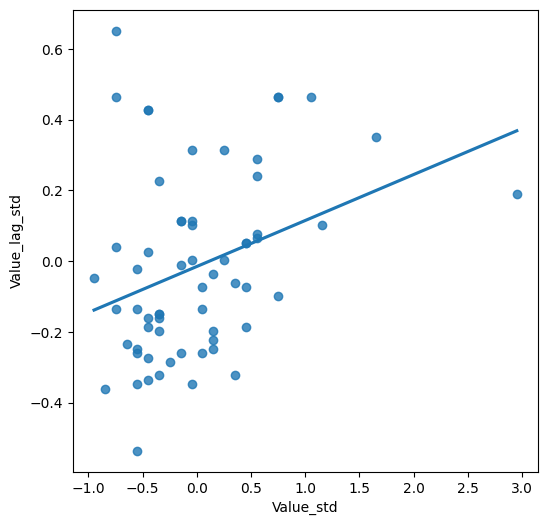

In [ ]:
f, ax = plt.subplots(1, figsize = (6,6))
seaborn.regplot(
    x = "Value_std",
    y = "Value_lag_std",
    data = db,
    ci = None,
)
plt.show()

##Global Moran’s I value


In [ ]:
# Calculate Global Moran's I
moran = esda.Moran(db['Value'], w)

# Print Moran's I statistic and its p-value
print(f"Global Moran's I: {moran.I:.4f}")

Global Moran's I: 0.1300


##p-value (e.g., p_sim) indicating statistical significance


In [ ]:
print(f"P-value (simulated): {moran.p_sim:.4f}")

P-value (simulated): 0.0080


#2. Local Spatial Autocorrelation (LISA)


##Moran scatterplot into quadrants


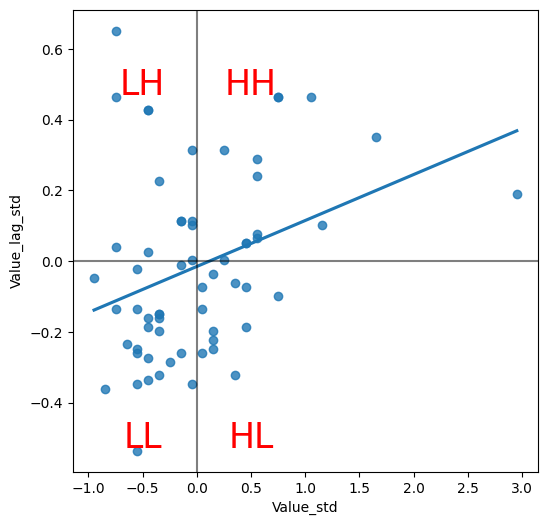

In [ ]:
f, ax = plt.subplots(1, figsize=(6,6))
seaborn.regplot(
    x = "Value_std",
    y = "Value_lag_std",
    ci=None,
    data=db,
)

# Add vertical and horizontal lines at zero (average)
plt.axvline(0, c="k", alpha=0.5)
plt.axhline(0, c="k", alpha=0.5)

# Add label of quadrants
# Adjusting coordinates to be within the typical range of standardized values (-2 to 2 or so)
plt.text(0.5, 0.5, "HH", fontsize=25, c="r", ha="center", va="center")
plt.text(0.5, -0.5, "HL", fontsize=25, c="r", ha="center", va="center")
plt.text(-0.5, 0.5, "LH", fontsize=25, c="r", ha="center", va="center")
plt.text(-0.5, -0.5, "LL", fontsize=25, c="r", ha="center", va="center")

plt.show()

#Local Morans I

In [ ]:
# Computes local Moran's I for each location
lisa = esda.moran.Moran_Local(db["Value"], w)

In [ ]:
lisa.Is

array([ 1.71826508e-01, -1.93571004e-01,  1.28707922e+00, -1.61719067e-02,
        5.37463960e-02,  1.63737556e-01,  5.37463960e-02, -6.93544454e-02,
        1.19201828e-01, -1.82041923e-01,  7.05976307e-01, -2.62187636e-01,
       -1.25458245e-02,  6.77618485e-01, -1.27317774e-02, -1.79954451e-04,
       -3.50461293e-02,  8.15463594e-02,  2.95725148e-02,  3.88701614e-02,
        2.69823704e-01,  1.82239872e-01,  9.74453351e-02,  1.33905307e+00,
        3.67727923e-01,  1.59367662e-01,  8.92634061e-02, -1.70512841e-01,
       -1.12445138e+00,  8.04345408e-01,  9.35763145e-04,  1.19201828e-01,
        3.14080502e-01, -2.75150355e-02, -7.80942332e-02, -7.64206568e-02,
       -1.13371304e-02, -6.74949160e-02,  8.04345408e-01,  3.29886501e-01,
        1.12539315e+00, -8.00893282e-01,  1.05813217e-01,  1.29243287e-01,
       -4.93645051e-02, -3.10481413e-02,  2.59782245e-01,  3.04132020e-01,
       -8.68340210e-02, -4.41074358e-01,  4.40528496e-01,  1.92188354e-01,
        2.34492646e-01,  

In [ ]:
from splot import esda as esdaplot
import pandas

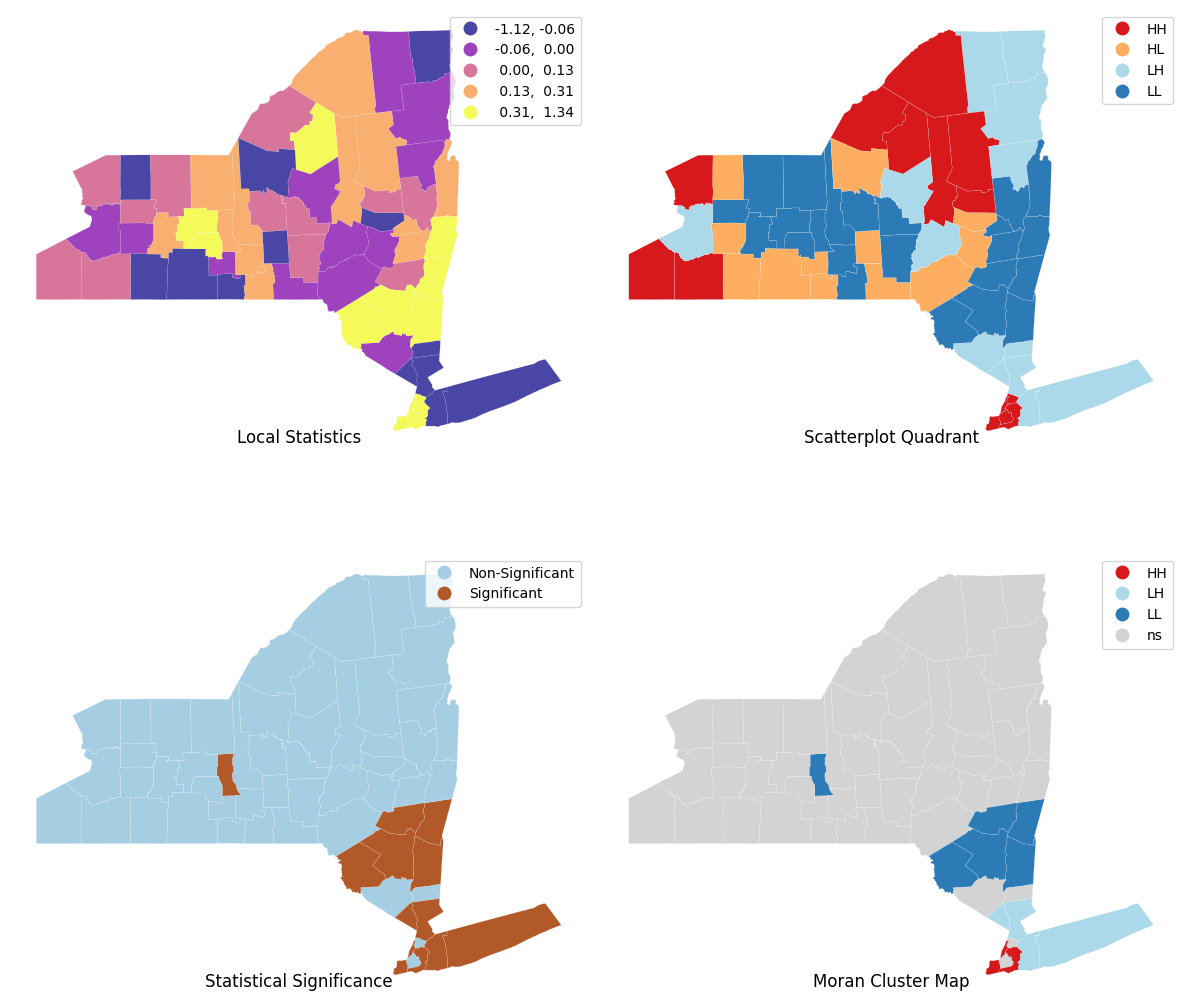

In [ ]:
#create a 2x2 grid of maps
f, axs = plt.subplots(nrows =2, ncols=2, figsize=(12,12))

#flatten axes array for easier indexing
axs = axs.flatten()

#1. Local statistics map
# Map of Local Moran statistics (Ii values)
ax =axs[0]
# Temporarily add Local Moran values to the dataframe
db.assign(Is=lisa.Is).plot(
    column = "Is",
    cmap="plasma",
    scheme="quantiles",
    k=5,
    edgecolor="white",
    linewidth = 0.1,
    alpha =0.75,
    legend=True,
    ax=ax,
)

#2. Subplot 2 - Quadrant classification
# Map showing the quadrant classification
# (HH, HL, LH, LL) based on the Moran scatterplot
ax = axs[1]
#Use p=1 so every observation receives a quadrant label
esdaplot.lisa_cluster(lisa, db, p=1, ax=ax)

#3. Statistical significance map
# Map showing which locations are statistically significant
ax=axs[2]
# Identify significant locations (p <0.05)
labels = pandas.Series(
    1 * (lisa.p_sim < 0.05), #Assign 1 if significant, 0 otherwise
     index = db.index # use the index in the original data
).map({1: "Significant", 0: "Non-Significant"}) #REcode 1 to "SiGNIFICANT and 0 to "Non-significant"

# Plot significance categories
db.assign(cl=labels).plot(
    column="cl",
    categorical=True,
    k=2,
    cmap="Paired",
    linewidth=0.1,
    edgecolor="white",
    legend=True,
    ax=ax,
)


# 4. LISA cluster map
# Map of statistically significant clusters
# (only locations with p < 0.05 are highlighted)
ax = axs[3]
esdaplot.lisa_cluster(lisa, db, p=0.05, ax=ax)



# Final figure styling
# Add titles to each subplot
for i, ax in enumerate(axs.flatten()):
    ax.set_axis_off()
    ax.set_title(
        [
            "Local Statistics",
            "Scatterplot Quadrant",
            "Statistical Significance",
            "Moran Cluster Map",
        ][i],
        y=0,
    )
# Adjust layout to minimize in-between white space
f.tight_layout()

# Display the figure
plt.show()

In [ ]:
#Inspect the first 10 quadrant classification
'''
1 --> HH
2 --> LH
3 --> LL
4 -->HL
'''
lisa.q[:10]

array([3, 4, 1, 4, 1, 3, 1, 4, 3, 2])

In [ ]:
counts = pandas.value_counts(lisa.q)
counts

/tmp/ipykernel_2142/3518240389.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  counts = pandas.value_counts(lisa.q)


,count
3,23
1,14
2,13
4,12


In [ ]:
# percentage of statistically significant location (over 95% confidence level)
(lisa.p_sim < 0.05).sum() * 100 / len(lisa.p_sim)

np.float64(20.967741935483872)

In [ ]:
#Add significance results to original dataframe

db['p-sim'] = lisa.p_sim

#Create binary significance flag (1 = significant)
sig = 1 * (lisa.p_sim <0.05)
db['sig'] = sig
db[["sig", "p-sim"]]

,sig,p-sim
0,0,0.309
1,0,0.235
2,0,0.114
3,0,0.319
4,0,0.354
...,...,...
57,1,0.047
58,0,0.393
59,0,0.112
60,0,0.474
